# **Tutorial 1 (Part-II):** Rock modeling

`Rock` Class is the base class for all rocks and is designed to simulate a real rock, therefore it includes many different properties that one may expect to see in a real rock, such as `mineralset`, `fluidset`, `total_porosity`, etc.

Generally three classes inherit from `Rock` class:
1. `SimpleRock`: A simple class without any added functionality aiming just to store different rock component. In this class elastic properties are assigned rather than be computed by an effective medium theory.
2. `InclusionRock`: A rather complicated class to model the rock and its elastic properties by inclusion methods such as *DEM*, *Self-Consistant*, etc. or even crack methods. 
3. `GranularRock`: A class to model the rock and its elastic properties based on the Contact-theory methods.


## Simple Rock Class
As indicated before this class does not support any special functionality beyond the base class `Rock` such that the key elastic properties *bulk* and *shear* are assigned to the rock (rather than be computed from a given effective medium theory). Other elstic properties, as well as velocities are calculated from the key properties on-the-fly. 

In [1]:
from rokpy.materials import  Mineral, MineralSet, Fluid, FluidSet,  SimpleRock
from rokpy.constants import MineralsPropertyTable, FluidsPropertyTable 
from rokpy.models import BoundMethods

# Define the rock mineralset (rock matrix) and its component
minerals_table = MineralsPropertyTable()
clay = Mineral(minerals_table.DryClay)
quartz = Mineral(minerals_table.Quartz)
calcite = Mineral(minerals_table.Calcite)
mineralset = MineralSet({clay: 0.4, calcite:0.3, quartz:0.3}, BoundMethods.MixingMethodName.VoigtReussHill)

# Define the rock fluidset and its components
fluid_props = FluidsPropertyTable()
brine = Fluid(fluid_props.Brine)
oil = Fluid(fluid_props.Oil)
gas = Fluid(fluid_props.Gas)
dry = Fluid(fluid_props.Dry)
fluidset = FluidSet({brine: 0.9, oil:0.1})

# Define the rock 
phit = 0.2  # or a vector of porosities np.array(0.2, dtype=float, ndmin=1)
rock = SimpleRock( mineralset, fluidset, phit, 3500, 2000)
print(rock)

Type                |    Density    |  P-velocity   |  S-velocity   |     Bulk      |     Shear     |    Poisson    
---------------------------------------------------------------------------------------------------------
Rock                |     2.337     |    3500.00    |    2000.00    |     16.16     |     9.35      |     0.258     



Defining one of the fluids, e.g. *brine*, as the bound (immobile) fluid, rock properties in effective system of porosity may be computed internally. Bound fluid is a property of `FluidSet`.

In [2]:
# bound fluid is a property of fluidset, therefore bound fluid of the rock is assigned indirectly as follows:
rock.fluidset.bound_fluid = brine

# total_porosity = effective_porosity + bound_porosity
rock.bound_fluid_porosity = 0.05 
print(f'Rock Total porosity:        {rock.total_porosity}')
print(f'Rock effective porosity:    {rock.effective_porosity}')


Rock Total porosity:        [0.2]
Rock effective porosity:    [0.15]


All `Rock` classes, including the `SimpleRock`s has a `dry_rock` property that returns a dry version of the rock. In dry rock, all fluids in the rock and the corresponding fluidset, except the immobile portion of bound fluid are excluded from the rock.

In [3]:
dry_rock = rock.dry_rock
print(f'Rock FluidSet: \n{rock.fluidset}')
print(f'Dry Rock FluidSet: \n{dry_rock.fluidset}') 
#Compare the *type* and *Fraction* column

Rock FluidSet: 
Type                |   Fraction    |    Density    |  P-velocity   |  S-velocity   |     Bulk      |     Shear     |    Poisson    
----------------------------------------------------------------------------------------------------------------------------------
Brine               |    0.9000     |     1.000     |    1600.00    |     0.00      |     2.56      |     0.00      |     0.500     
Oil                 |    0.1000     |     0.800     |    1200.00    |     0.00      |     1.15      |     0.00      |     0.500     
----------------------------------------------------------------------------------------------------------------------------------
FluidSet            |     1.000     |     0.980     |    1525.69    |     0.00      |     2.28      |     0.00      |     0.500     

Dry Rock FluidSet: 
Type                |   Fraction    |    Density    |  P-velocity   |  S-velocity   |     Bulk      |     Shear     |    Poisson    
------------------------------------

c:\Users\MAbbasi\MEGA\Python\virtualenvs\General\Lib\site-packages\rokpy\conversions.py:187: RuntimeWarning: invalid value encountered in divide
  return (3*bulk-2*shear)/(6*bulk+2*shear)


`Rock` objects have many realistic attributes that can be easily accessed:

In [4]:
print(f'Rock MineralSet: \n{rock.mineralset}')

print(f'Rock P-wave Velocity:   {rock.p_velocity}')
print(f'Rock Density:           {rock.density}')
print(f'Rock Fluids: \n{rock.fluids}')

Rock MineralSet: 
Type                |   Fraction    |    Density    |  P-velocity   |  S-velocity   |     Bulk      |     Shear     |    Poisson    
----------------------------------------------------------------------------------------------------------------------------------
DryClay             |    0.4000     |     2.670     |    3538.62    |    1784.24    |     22.10     |     8.50      |     0.330     
Calcite             |    0.3000     |     2.710     |    6253.17    |    3420.15    |     63.70     |     31.70     |     0.287     
Quartz              |    0.3000     |     2.650     |    6037.62    |    4120.82    |     36.60     |     45.00     |     0.064     
----------------------------------------------------------------------------------------------------------------------------------
MineralSet          |     1.000     |     2.676     |    4880.79    |    2809.19    |     35.59     |     21.12     |     0.252     

Rock P-wave Velocity:   [3500.]
Rock Density:         

One of the most interesting properties of the `Rock`s is that the porosity corresponding to each mineral is not necessary  proportional to volume fractions (despite the assumptions in Xu-White (1995) or Xu-Payne (2009) models), because obviously different mineralogies have different orders of porosities, for example, in most cases, same volumes of shale (Clay) definitely has more total porosity than Limestone (Calcite). 
This will give much more flexibility during modeling of the rock especially in the `InclusionRock`.

In [5]:
import numpy as np
np.set_printoptions(precision=3)

print("Default (Proportional) Porosity weight")
mineralset.set_porosity_weight(calcite, 1) # This is default value for all minerals
print(f'Clay Porosity:      {rock.mineral_porosity(clay)}')
print(f'Quartz Porosity:    {rock.mineral_porosity(quartz)}')
print(f'Calcite Porosity:   {rock.mineral_porosity(calcite)}')


print("\nModified Porosity weights")
mineralset.set_porosity_weight(calcite, 0.5) #Calcite porosity is usually much less than clay and quartz
print(f'Clay Porosity:      {rock.mineral_porosity(clay)}')
print(f'Quartz Porosity:    {rock.mineral_porosity(quartz)}')
print(f'Calcite Porosity:   {rock.mineral_porosity(calcite)}')


Default (Proportional) Porosity weight
Clay Porosity:      [0.08]
Quartz Porosity:    [0.06]
Calcite Porosity:   [0.06]

Modified Porosity weights
Clay Porosity:      [0.094]
Quartz Porosity:    [0.071]
Calcite Porosity:   [0.035]


## Inclusion Rock Model

`InclusionRock` is designed to represent the rocks that their pore structure is modeled by inclusion methods. Pore inclusions are defined by `Inclusion` data-class that stores the pore shape, pore aspect ratio, pore content, host, and the pore fraction of the inclusion in the host material. 

Each mineralogy may host zero, one or multiple inclusions. In cases where several inclusions share the same host (e.g. reference, crack and stiff pores in carbonates, in Xu-Payne model), corresponding porosities will be partitioned according their `fraction_in_host` attribute of `Inclusion`. 

As indicated before, since same volume of different lithologies have different orders of porosities, the porosity corresponding to each lithology is not necessarily proportional to their volume fractions. In `rokpy` user may assign different porosity weights (default is 1) to different mineralogies to account for this issue. This will give more flexibility during modeling the rock and will lead to much reliable values of pore aspect ratios.

In `InclusionRock`s, inclusions containing bound fluid are included by their pore content while for other inclusions this is done in two separate steps: first dry inclusion is added, and then the pore content is added by the fluid substitution method (Gassman or Dvorkin et al., 1995 models).

Following is an example showing how we can build a rock of the Xu-Payne (2009) model:

In [6]:
from rokpy.materials import  Mineral, MineralSet,Fluid, FluidSet,  InclusionRock
from rokpy.constants import MineralsPropertyTable, FluidsPropertyTable
from rokpy.effective_medium import ShapeName, BoundMethods, InclusionMethods, Inclusion
from rokpy import conversions
import numpy as np
np.set_printoptions(precision=3)

# Define mineralset
minerals_table = MineralsPropertyTable()
clay = Mineral(minerals_table.DryClay)
calcite = Mineral(minerals_table.Calcite)
mineralset = MineralSet({clay: 0.2, calcite:0.6}, BoundMethods.MixingMethodName.VoigtReussHill)

# Define the fluidset
fluid_props = FluidsPropertyTable()
brine = Fluid(fluid_props.Brine)
oil = Fluid(fluid_props.Oil)
gas = Fluid(fluid_props.Gas)
dry = Fluid(fluid_props.Dry)
fluidset = FluidSet({brine: 0.2, oil:0.8}) #By default, Brine fluid is selected as bound fluid


# Define the Rock
phit = 0.2
rock = InclusionRock( mineralset, fluidset, phit, InclusionMethods.InclusionMethodName.DEM)

# Define Inclusions
clay_inclusion =                Inclusion(ShapeName.SPHEROID, aspect_ratio=0.05, content=fluidset.bound_fluid)
calcite_reference_inclusion =   Inclusion(ShapeName.SPHEROID, aspect_ratio=0.15) 
calcite_crack_inclusion =       Inclusion(ShapeName.SPHEROID, aspect_ratio=0.03)
calcite_stiff_inclusion =       Inclusion(ShapeName.SPHEROID, aspect_ratio=0.50) 

# Modify porosity weight
# mineralset.set_porosity_weight(clay, 5)

# Add inclusions to the rock 
# Note: fractions in the host must add-up to unity.
rock.add_inclusion(clay_inclusion, host = clay)
rock.add_inclusion(calcite_reference_inclusion, host = calcite, fraction_in_host =0.2) 
rock.add_inclusion(calcite_crack_inclusion, host = calcite, fraction_in_host = 0.2)
rock.add_inclusion(calcite_stiff_inclusion, host = calcite, fraction_in_host = 0.6)

print (rock)

Type                |    Density    |  P-velocity   |  S-velocity   |     Bulk      |     Shear     |    Poisson    
---------------------------------------------------------------------------------------------------------
Rock                |     2.328     |    3199.97    |    1851.54    |     13.20     |     7.98      |     0.248     



Now the rock is fully defined and as you can see its elastic properties is internally calculated. But the rock properties is not limited to these elastic attributes. Let's inspect some of these attributes:

In [7]:
# Specify the porosity of a given inclusion
print(f"Porosity of crack inclusion: {rock.inclusion_porosity(calcite_crack_inclusion)}\n")

# Dynamically modify some specification
clay_inclusion.aspect_ratio = 0.09

print(f"List of Inclusions in the rock:\n{rock.inclusion_set}\n")
# print(f"List of minerals in the rock: \n{rock.minerals}\n")
print(f"Rock's Fluidset: \n{rock.fluidset}\n")

print("Classifcation of rock porosities:")
print("Rock's Total Porosity: {}".format(rock.total_porosity))
print("Rock's Bound Porosity: {}".format(rock.bound_fluid_porosity))
print("Rock's effective Porosity: {}".format(rock.effective_porosity))


Porosity of crack inclusion: [0.03]

List of Inclusions in the rock:
{(Shape=ShapeName.SPHEROID, Content=Brine, aspect(mean)=0.09, Host=DryClay): array([0.05]), (Shape=ShapeName.SPHEROID, Content=Dry, aspect(mean)=0.15, Host=Calcite): array([0.03]), (Shape=ShapeName.SPHEROID, Content=Dry, aspect(mean)=0.03, Host=Calcite): array([0.03]), (Shape=ShapeName.SPHEROID, Content=Dry, aspect(mean)=0.50, Host=Calcite): array([0.09])}

Rock's Fluidset: 
Type                |   Fraction    |    Density    |  P-velocity   |  S-velocity   |     Bulk      |     Shear     |    Poisson    
----------------------------------------------------------------------------------------------------------------------------------
Brine               |    0.2000     |     1.000     |    1600.00    |     0.00      |     2.56      |     0.00      |     0.500     
Oil                 |    0.8000     |     0.800     |    1200.00    |     0.00      |     1.15      |     0.00      |     0.500     
-----------------------

`Rock`s in the `rokpy` use the Dvorkin's model (Dvorkin et al., 1995) for fluid substitution, that compute the saturated rock properties for any given frequency (Gassmann model is limited to low frequencies). Dvorkin et al.'s model at low frequencies (below characteristic frequency, fc) converges to Gassmann model. The frequency of calculation can be set through the `rock.analysis_frequency`.
Dvorkin's fluid substitution model also has a tuning parameter, Z, that is also stored in the rock. This property may be tuned through comparing the measured and calculated rock moduli.
`InclusionRock` has four different types (class methods) of bulk and shear moduli measurements:
- `moduli()`: Returns final saturated bulk and shear moduli of the rock (effective moduli of th rock)
- `frame_moduli()`: Returns the dry frame rock moduli where only bound fluid is incorporated into the rock
- `wetsolid_moduli()`: Returns the rock matrix moduli mixed with bound fluid
- `hiPressure_dry_moduli()`: Returns the rock frame moduli when only stiff inclusions are incorporated and compliance inclusions are assumed to be closed under high pressure. Stiff pores are specified in 'Inclusion' definition. This moduli are used in Dvorkin's model.

In following codes you can see how rock properties are changed for different frequencies:

In [8]:
rock.Z = 0.003
rock.viscosity_to_permeability = 0.2
print(f'Rock Characteristic frequency (that discriminate the low and high frequencies: {rock.biot_characteristic_frequency/1e6} MHz)\n')
rock.analysis_frequency=1 #this is default value
print(f'rock properties at low frequency:\n{rock}\n')
rock.analysis_frequency = 10e6
print(f'rock properties at frequency of {rock.analysis_frequency/1e6} MHz:\n{rock}\n')

Rock Characteristic frequency (that discriminate the low and high frequencies: [7.579] MHz)

rock properties at low frequency:
Type                |    Density    |  P-velocity   |  S-velocity   |     Bulk      |     Shear     |    Poisson    
---------------------------------------------------------------------------------------------------------
Rock                |     2.328     |    3352.00    |    1953.81    |     14.31     |     8.89      |     0.243     


rock properties at frequency of 10.0 MHz:
Type                |    Density    |  P-velocity   |  S-velocity   |     Bulk      |     Shear     |    Poisson    
---------------------------------------------------------------------------------------------------------
Rock                |     2.328     |    4893.89    |    2130.92    |     41.66     |     10.57     |     0.383     




We can also inspect the behavior of rock P-wave velocity as a function of measurement frequency.

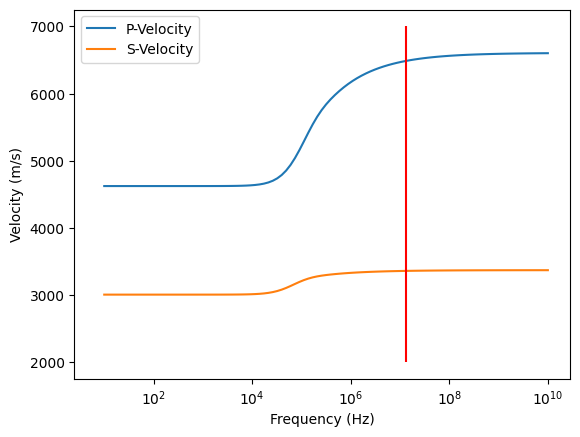

In [39]:
import matplotlib.pyplot as plt

freq = np.logspace(1,10,101)
rock.analysis_frequency = freq
plt.semilogx(freq,rock.p_velocity, freq,rock.s_velocity)
plt.vlines(rock.biot_characteristic_frequency,2000, 7000, 'r', label='fc')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Velocity (m/s)')
plt.legend(["P-Velocity", "S-Velocity"])


Following is another example of analyzing the rock. In this example we simply inspect how saturated and dry rock's Vp/Vs ratio behave differently with respect to porosity.

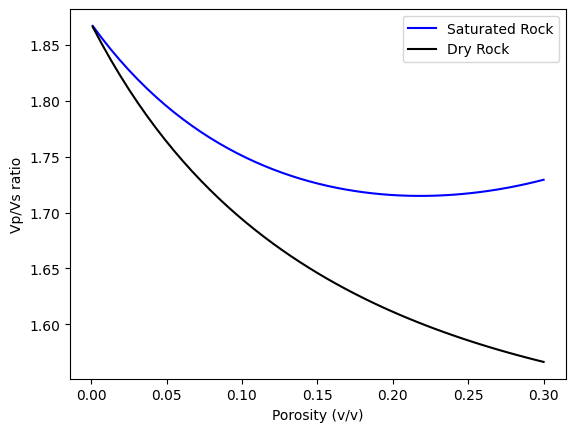

In [10]:
# First Roll back the frequency range of previous steps to a sigle scalar:
rock.analysis_frequency = 1

# Define a range of total porosities and assign it to the rock
phit = np.linspace(0.001, 0.3, 51) #
rock.total_porosity = phit


plt.plot(phit, rock.velocity_ratio, 'b')
plt.plot(phit, rock.dry_rock.velocity_ratio, 'k')
plt.legend(["Saturated Rock","Dry Rock"])
plt.xlabel('Porosity (v/v)')
plt.ylabel('Vp/Vs ratio')
plt.show()

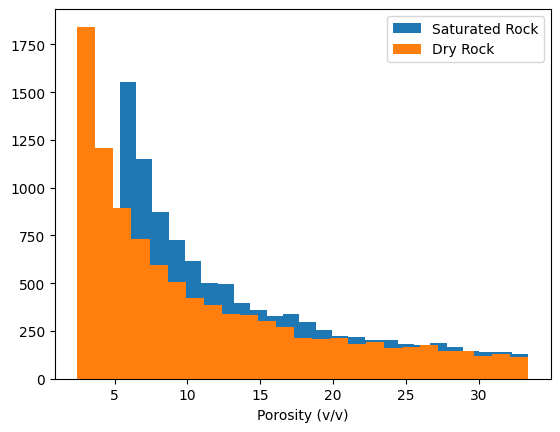

In [11]:

# Define a random set of total porosities and assign it to the rock
rock.total_porosity = np.random.uniform(0, 0.3, size = 10000)


plt.hist(rock.lame, 25)
plt.hist(rock.dry_rock.lame, 25)
plt.legend(["Saturated Rock","Dry Rock"])
plt.xlabel('Porosity (v/v)')
plt.show()

## Granular Rock

Another class of rocks are `GranularRock` that simulate the clastic rocks using the contact models. This class of rock requires some extra parameters including contact number, hydrostatic pressure, adhesion coefficient, contact cement and its saturation. 


In [12]:
from rokpy.materials import Material, Mineral, MineralSet,Fluid, FluidSet,  GranularRock
from rokpy.constants import MineralsPropertyTable, FluidsPropertyTable
from rokpy.effective_medium import BoundMethods, ContactMethods
from inspect import signature

# Drfine mineralset
minerals_table = MineralsPropertyTable()
clay = Mineral(minerals_table.DryClay)
quartz = Mineral(minerals_table.Quartz)
mineralset = MineralSet({clay: 0.25, quartz:0.3}, BoundMethods.MixingMethodName.VoigtReussHill)

# Define fluidset
fluid_props = FluidsPropertyTable()
brine = Fluid(fluid_props.Brine)
oil = Fluid(fluid_props.Oil)
gas = Fluid(fluid_props.Gas)
fluidset = FluidSet({brine: 0.9, oil:0.1})

# Define Cement
cement = Material(2800, 1500, 2.3) # or e.g. Mineral(minerals_table.Kaolinite)

# Define rock
phit = 0.2
rock = GranularRock(mineralset, fluidset, phit, ContactMethods.ContactMethodName.IntermediateStiffSand,
                                                critical_porosity=0.4, \
                                                contact_no=10, \
                                                pressure=20, \
                                                adhesion_coef=1,  \
                                                contact_cement_saturation = 0.5, \
                                                cement = cement)
rock.analysis_frequency = 1e2
print(rock)


Type                |    Density    |  P-velocity   |  S-velocity   |     Bulk      |     Shear     |    Poisson    
---------------------------------------------------------------------------------------------------------
Rock                |     2.323     |    4622.95    |    3007.43    |     21.63     |     21.01     |     0.133     



## Flexiblity of Models: Create Shale mineral by inclusion model

The rock models has many hidden capabilities that the user may take advantage of. An example is to build the shale mineralogy using the `InclusionRock` and use it as a separate mineral in the mineralset. 

To inspect this, in following example, we build two different scenarios to model a rock:
- **Scenario I:** Rock made by a modeled Shale
- **Scenario II:** Rock made simply from Clay

To be comparable, these two scnarios need to have a compatible properties in total and effective system of porosities. Assuming that the shale porosity refers to the bound fluid porosity, we use effective porosity for the rock of Scenario I and total porosity for the rock of Scenario II.

The properties that need to be compatible in these two systems are porosities, volume fractions and saturations.

In [13]:
from rokpy.materials import  Mineral, MineralSet,Fluid, FluidSet,  InclusionRock
from rokpy.constants import MineralsPropertyTable, FluidsPropertyTable
from rokpy.effective_medium import ShapeName, Inclusion, InclusionMethods, BoundMethods
from rokpy.conversions import total_to_effective_saturation_bound, shale_to_clay_fraction, effective_to_total_fraction

# Calculate a compatible set of properties in Total and Effective system of porosities:
phit = 0.20                     #Total porosity
Vsh = 0.6                       #Shale volume
Vsst = 1-Vsh                    #Sandstone volume
Swt = 0.6
phie = phit*(1-Vsh)
phibound = phit-phie

# Properties fractions in Effective system
Vqz_e = ((1-Vsh)-phie)/(1-phie) #Quartz Normalized volume in effective system
Vsh_e = Vsh/(1-phie)            #Shale volume (as a mineral) normalized volume
Swe = total_to_effective_saturation_bound(Swt, phit, phie)

# Properties fractions in Effective system
Vcl_t = shale_to_clay_fraction(Vsh, phit, phie)
Vqz_t = effective_to_total_fraction(Vqz_e, phit, phie)

# Define fluids
fluid_props = FluidsPropertyTable()
brine = Fluid(fluid_props.Brine)
oil = Fluid(fluid_props.Oil)
dry = Fluid(fluid_props.Dry)

# Define minerals
minerals_table = MineralsPropertyTable()
clay = Mineral(minerals_table.DryClay)
quartz = Mineral(minerals_table.Quartz)

# Shale (as a rock) properties
phi_shale_rock = phibound/Vsh
shale_density = clay.density*(1-phi_shale_rock) + brine.density*phi_shale_rock

# Define inclusions
clay_inclusion = Inclusion(ShapeName.SPHEROID, 0.05, brine, clay)
quartz_inclusion = Inclusion(ShapeName.SPHEROID, 0.12, dry, quartz)


# Create Shale mineral by incorporating corresponding inclusion
shale = InclusionRock( clay, brine, phi_shale_rock, InclusionMethods.InclusionMethodName.DEM)
shale.add_inclusion(clay_inclusion, clay)
shale.type = "Modeled_Shale"

print(f'Compare Clay mineral with modeled shale:\n{clay}\n{shale}')

Compare Clay mineral with modeled shale:
Type                |    Density    |  P-velocity   |  S-velocity   |     Bulk      |     Shear     |    Poisson    
---------------------------------------------------------------------------------------------------------
DryClay             |     2.670     |    3538.62    |    1784.24    |     22.10     |     8.50      |     0.330     

Type                |    Density    |  P-velocity   |  S-velocity   |     Bulk      |     Shear     |    Poisson    
---------------------------------------------------------------------------------------------------------
Modeled_Shale       |     2.336     |    2346.67    |    1032.54    |     9.54      |     2.49      |     0.380     



Now we build the rocks of bespoken scenarios:

In [14]:
# Create the rock by modeled shale + other minerals
shale_mineralset = MineralSet({shale: Vsh_e ,   quartz:Vqz_e  }, BoundMethods.MixingMethodName.HashinShtrikmanWalpole)
shale_fluidset = FluidSet({brine: Swe, oil: 1-Swe})
rock_with_shale = InclusionRock( shale_mineralset, shale_fluidset, phie, InclusionMethods.InclusionMethodName.DEM)
rock_with_shale.add_inclusion(quartz_inclusion, quartz)
rock_with_shale.type = "Rock_with_Shale"

# Create the rock by clay + other minerals
clay_mineralset  = MineralSet({clay : Vcl_t, quartz:Vqz_t}, BoundMethods.MixingMethodName.HashinShtrikmanWalpole)
clay_fluidset  = FluidSet({brine: Swt, oil:1-Swt})
rock_with_clay  = InclusionRock( clay_mineralset , clay_fluidset , phit, InclusionMethods.InclusionMethodName.DEM)
rock_with_clay.add_inclusion(clay_inclusion, clay)
rock_with_clay.add_inclusion(quartz_inclusion, quartz)
rock_with_clay.type = "Rock_with_Clay"

rock.porosity_weight
print(rock_with_shale)
print(rock_with_clay)

Type                |    Density    |  P-velocity   |  S-velocity   |     Bulk      |     Shear     |    Poisson    
---------------------------------------------------------------------------------------------------------
Rock_with_Shale     |     2.314     |    2826.61    |    1591.80    |     10.67     |     5.86      |     0.268     

Type                |    Density    |  P-velocity   |  S-velocity   |     Bulk      |     Shear     |    Poisson    
---------------------------------------------------------------------------------------------------------
Rock_with_Clay      |     2.313     |    2787.48    |    1562.49    |     10.44     |     5.65      |     0.271     

